In [ ]:
!pip install -q transformers torch pandas scikit-learn seaborn matplotlib scipy

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import random
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def lock_random_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
lock_random_seeds(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"System ready. Using device: {device}")

!wget -q -O mtsamples.csv "https://raw.githubusercontent.com/socd06/private_nlp/master/data/mtsamples.csv"
if os.path.getsize("mtsamples.csv") < 1000:
    !wget -q -O mtsamples.csv "https://raw.githubusercontent.com/JunaidFarooqZargar/clinical_text_classification/master/mtsamples.csv"

real_df = pd.read_csv("mtsamples.csv")[['transcription', 'medical_specialty']].dropna()
real_df = real_df.rename(columns={"transcription": "Symptoms", "medical_specialty": "Diagnosis"})
top_5 = real_df['Diagnosis'].value_counts().nlargest(5).index
real_df = real_df[real_df['Diagnosis'].isin(top_5)].reset_index(drop=True)

#  Strict Train (70%) / Val (15%) / Test (15%) Split ---
train_df, temp_df = train_test_split(real_df, test_size=0.30, random_state=42, stratify=real_df['Diagnosis'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['Diagnosis'])

train_retain, train_forget = train_test_split(train_df, test_size=0.20, random_state=42, stratify=train_df['Diagnosis'])

#  Advanced PII Injection (Random placement to prevent positional cheating)
def inject_pii_randomly(text):
    names = ["John Doe", "Jane Smith", "Robert Johnson", "Emily Davis", "Michael Brown"]
    ssn = f"{random.randint(100,999)}-{random.randint(10,99)}-{random.randint(1000,9999)}"
    words = str(text).split()
    if len(words) > 0:
        words.insert(random.randint(0, len(words) // 2), f" [CONFIDENTIAL: Pt {random.choice(names)}, SSN {ssn}] ")
    return " ".join(words)

train_forget['Symptoms'] = train_forget['Symptoms'].apply(inject_pii_randomly)

# Prevent Data Leakage: Fit Encoder ONLY on Train Data ---
label_encoder = LabelEncoder()
label_encoder.fit(train_df['Diagnosis'])
num_classes = len(label_encoder.classes_)

print(f"✅ Splits Ready! Train: {len(train_df)} (Retain: {len(train_retain)}, Forget: {len(train_forget)}) | Val: {len(val_df)} | Test: {len(test_df)}")

System ready. Using device: cuda
✅ Splits Ready! Train: 1822 (Retain: 1457, Forget: 365) | Val: 390 | Test: 391


In [ ]:
print("Initializing Tokenizer and DataLoaders (Max Length: 256)...")

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")

class HealthcareDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts, self.labels, self.tokenizer = texts, labels, tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        encoding = self.tokenizer(str(self.texts[idx]), max_length=self.max_length, padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': encoding['input_ids'].flatten(), 'attention_mask': encoding['attention_mask'].flatten(), 'labels': torch.tensor(self.labels[idx], dtype=torch.long)}

# DataLoaders
train_retain_loader = DataLoader(HealthcareDataset(train_retain['Symptoms'].tolist(), label_encoder.transform(train_retain['Diagnosis']), tokenizer), batch_size=16, shuffle=True)
train_forget_loader = DataLoader(HealthcareDataset(train_forget['Symptoms'].tolist(), label_encoder.transform(train_forget['Diagnosis']), tokenizer), batch_size=16, shuffle=True)
val_loader = DataLoader(HealthcareDataset(val_df['Symptoms'].tolist(), label_encoder.transform(val_df['Diagnosis']), tokenizer), batch_size=16, shuffle=False)
test_loader = DataLoader(HealthcareDataset(test_df['Symptoms'].tolist(), label_encoder.transform(test_df['Diagnosis']), tokenizer), batch_size=16, shuffle=False)

# Dimension-Locked Advanced Attacker
class ThesisAttacker(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(num_classes + 1, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, logits, entropy): return self.net(torch.cat((logits, entropy), dim=1))

print("✅ Architecture Ready!")

Initializing Tokenizer and DataLoaders (Max Length: 256)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✅ Architecture Ready!


In [ ]:
def run_thesis_experiment(method="kantian", lambda_val=50.0, epochs=5):
    print(f"\n🚀 STARTING: {method.upper()} (Lambda: {lambda_val})")
    defender = AutoModelForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=num_classes).to(device)
    opt_def = torch.optim.AdamW(defender.parameters(), lr=2e-5)
    attacker = ThesisAttacker(num_classes).to(device)
    opt_att = torch.optim.Adam(attacker.parameters(), lr=1e-3)
    crit_util = nn.CrossEntropyLoss(); crit_att = nn.BCELoss()

    start_time = time.time()
    history = {'epoch': [], 'val_f1': [], 'mia_risk': []}

    for epoch in range(epochs):
        #  TRAINING
        defender.train(); attacker.train()
        for r_batch, f_batch in zip(train_retain_loader, train_forget_loader):
            r_input_ids, r_attn_mask, r_labels = r_batch['input_ids'].to(device), r_batch['attention_mask'].to(device), r_batch['labels'].to(device)
            f_input_ids, f_attn_mask, f_labels = f_batch['input_ids'].to(device), f_batch['attention_mask'].to(device), f_batch['labels'].to(device)

            #  Attacker
            opt_att.zero_grad()
            with torch.no_grad():
                r_log, f_log = defender(input_ids=r_input_ids, attention_mask=r_attn_mask).logits, defender(input_ids=f_input_ids, attention_mask=f_attn_mask).logits
            r_prob, f_prob = F.softmax(r_log, dim=1), F.softmax(f_log, dim=1)
            r_ent, f_ent = -torch.sum(r_prob * torch.log(r_prob + 1e-9), dim=1, keepdim=True), -torch.sum(f_prob * torch.log(f_prob + 1e-9), dim=1, keepdim=True)
            pred_r, pred_f = attacker(r_log, r_ent).squeeze(-1), attacker(f_log, f_ent).squeeze(-1)
            loss_att = (crit_att(pred_r, torch.zeros_like(pred_r)) + crit_att(pred_f, torch.ones_like(pred_f))) / 2
            loss_att.backward(); opt_att.step()

            #  Defender
            opt_def.zero_grad()
            r_out = defender(input_ids=r_input_ids, attention_mask=r_attn_mask)
            loss_u = crit_util(r_out.logits, r_labels)

            if method == "kantian":
                f_out = defender(input_ids=f_input_ids, attention_mask=f_attn_mask)
                f_prob_def = F.softmax(f_out.logits, dim=1)
                f_ent_def = -torch.sum(f_prob_def * torch.log(f_prob_def + 1e-9), dim=1, keepdim=True)
                privacy_violation = torch.relu(attacker(f_out.logits, f_ent_def).squeeze(-1).mean() - 0.51)
                loss_def = loss_u + (lambda_val * privacy_violation)
            elif method == "gradient_ascent":
                f_out = defender(input_ids=f_input_ids, attention_mask=f_attn_mask)
                loss_def = loss_u - (0.5 * crit_util(f_out.logits, f_labels))
            loss_def.backward(); opt_def.step()

        # EPOCH VALIDATION TRACKING
        defender.eval(); attacker.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for b in val_loader:
                logits = defender(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device)).logits
                val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy()); val_labels.extend(b['labels'].cpu().numpy())
        val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

        att_preds, att_labels = [], []
        with torch.no_grad():
            for rb, fb in zip(train_retain_loader, train_forget_loader):
                r_log, f_log = defender(input_ids=rb['input_ids'].to(device), attention_mask=rb['attention_mask'].to(device)).logits, defender(input_ids=fb['input_ids'].to(device), attention_mask=fb['attention_mask'].to(device)).logits
                r_ent = -torch.sum(F.softmax(r_log, dim=1) * torch.log(F.softmax(r_log, dim=1) + 1e-9), dim=1, keepdim=True)
                f_ent = -torch.sum(F.softmax(f_log, dim=1) * torch.log(F.softmax(f_log, dim=1) + 1e-9), dim=1, keepdim=True)
                pr, pf = attacker(r_log, r_ent).squeeze(-1).cpu().numpy(), attacker(f_log, f_ent).squeeze(-1).cpu().numpy()
                att_preds.extend(pr); att_labels.extend([0]*len(pr)); att_preds.extend(pf); att_labels.extend([1]*len(pf))
                break

        history['epoch'].append(epoch + 1); history['val_f1'].append(val_f1); history['mia_risk'].append(np.mean((np.array(att_preds) >= 0.5) == np.array(att_labels)))

    elapsed_time = time.time() - start_time

    #  STRICT TEST EVALUATION
    defender.eval(); attacker.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for b in test_loader:
            logits = defender(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device)).logits
            test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy()); test_labels.extend(b['labels'].cpu().numpy())
    test_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)

    # Full MIA Eval
    all_att_preds, all_att_labels, probs_r, probs_f = [], [], [], []
    with torch.no_grad():
        for rb in train_retain_loader:
            r_log = defender(input_ids=rb['input_ids'].to(device), attention_mask=rb['attention_mask'].to(device)).logits
            r_ent = -torch.sum(F.softmax(r_log, dim=1) * torch.log(F.softmax(r_log, dim=1) + 1e-9), dim=1, keepdim=True)
            pr = attacker(r_log, r_ent).squeeze(-1).cpu().numpy()
            all_att_preds.extend(pr); all_att_labels.extend([0]*len(pr)); probs_r.extend(pr)
        for fb in train_forget_loader:
            f_log = defender(input_ids=fb['input_ids'].to(device), attention_mask=fb['attention_mask'].to(device)).logits
            f_ent = -torch.sum(F.softmax(f_log, dim=1) * torch.log(F.softmax(f_log, dim=1) + 1e-9), dim=1, keepdim=True)
            pf = attacker(f_log, f_ent).squeeze(-1).cpu().numpy()
            all_att_preds.extend(pf); all_att_labels.extend([1]*len(pf)); probs_f.extend(pf)

    final_mia = np.mean((np.array(all_att_preds) >= 0.5) == np.array(all_att_labels))
    print(f"Result -> Test F1: {test_f1:.4f} | Final Risk: {final_mia:.4f} | Time: {elapsed_time:.1f}s")

    return {"f1": test_f1, "mia": final_mia, "time": elapsed_time, "probs_retain": probs_r, "probs_forget": probs_f, "history": history, "def_weights": defender.state_dict(), "att_weights": attacker.state_dict()}

In [ ]:
# Execute Suite
thesis_results = {}
thesis_results["Kantian (Lambda=10)"] = run_thesis_experiment("kantian", lambda_val=10.0)
thesis_results["Kantian (Lambda=50)"] = run_thesis_experiment("kantian", lambda_val=50.0) # THE MASTER MODEL
thesis_results["Kantian (Lambda=100)"] = run_thesis_experiment("kantian", lambda_val=100.0)
thesis_results["Gradient Ascent"] = run_thesis_experiment("gradient_ascent", lambda_val=0.0)

# Export Data to CSV
csv_data = []
for m, metrics in thesis_results.items():
    csv_data.append({"Methodology": m, "Test F1 Score": round(metrics["f1"], 4), "MIA Risk": round(metrics["mia"], 4)})
results_df = pd.DataFrame(csv_data)
results_df.to_csv("Thesis_Final_Metrics.csv", index=False)
print("\n✅ Execution Complete! Results saved to 'Thesis_Final_Metrics.csv'.")
display(results_df)

# EXPORT WEIGHTS FOR HUGGINGFACE UI
torch.save(thesis_results["Kantian (Lambda=50)"]["def_weights"], 'kantian_defender_weights.pt')
torch.save(thesis_results["Gradient Ascent"]["def_weights"], 'baseline_defender_weights.pt')
torch.save(thesis_results["Kantian (Lambda=50)"]["att_weights"], 'advanced_attacker_weights.pt')


🚀 STARTING: KANTIAN (Lambda: 10.0)


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

...

Result -> Test F1: 0.3084 | Final Risk: 0.4468 | Time: 254.4s

🚀 STARTING: GRADIENT_ASCENT (Lambda: 0.0)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Result -> Test F1: 0.5546 | Final Risk: 0.7371 | Time: 261.5s

✅ Execution Complete! Results saved to 'Thesis_Final_Metrics.csv'.


,Methodology,Test F1 Score,MIA Risk
0,Kantian (Lambda=10),0.6114,0.5296
1,Kantian (Lambda=50),0.5104,0.5423
2,Kantian (Lambda=100),0.3084,0.4468
3,Gradient Ascent,0.5546,0.7371


Generating Academic Deliverables...


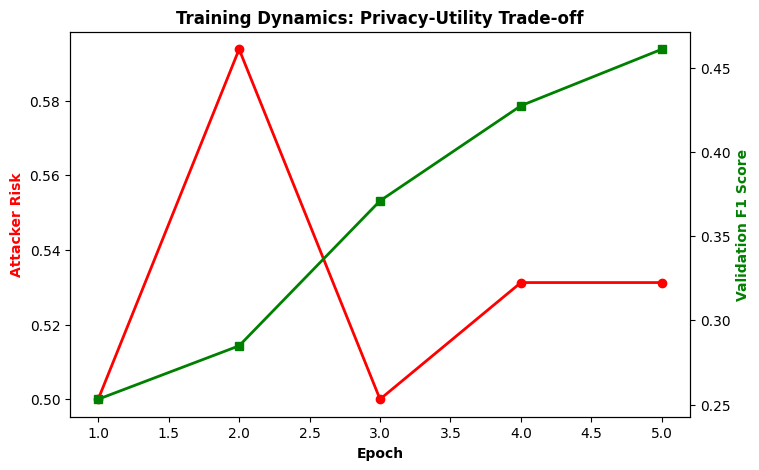

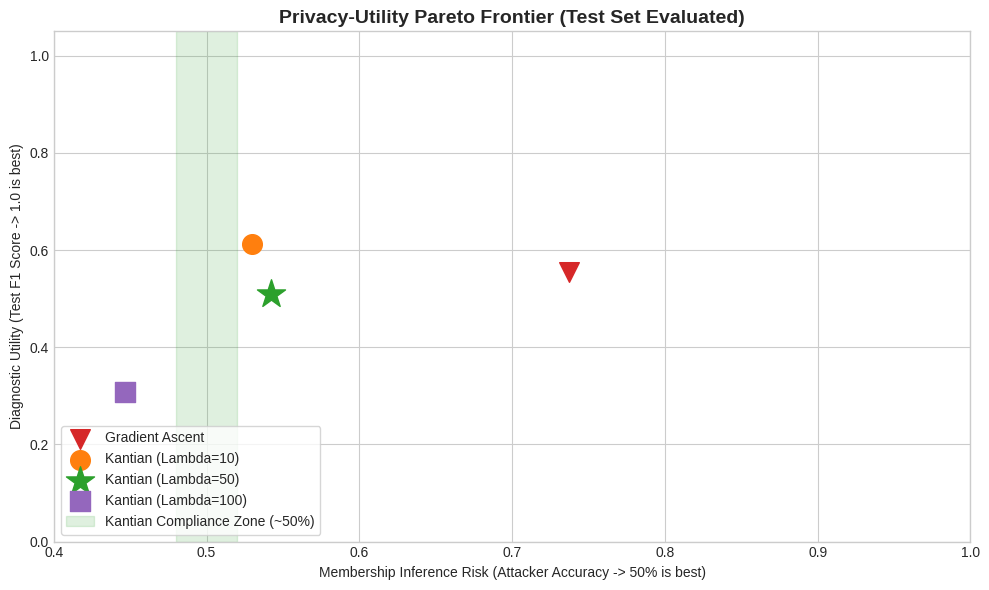

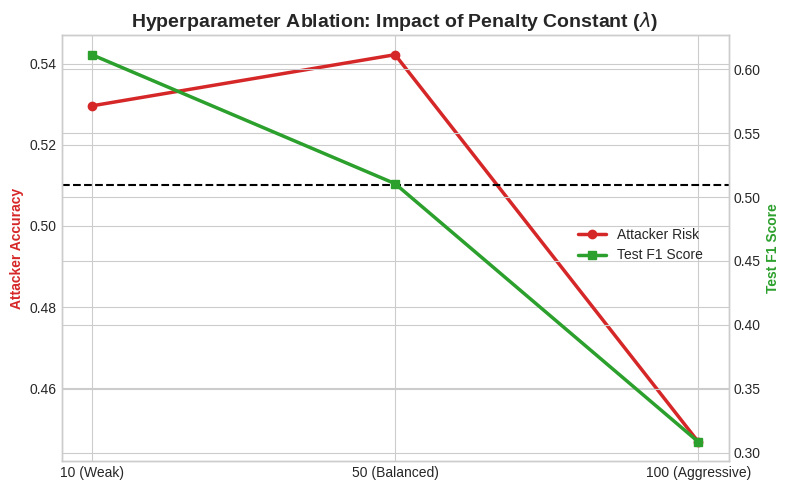

In [ ]:
print("Generating Academic Deliverables...")

# 1. Learning Curves (Training Dynamics)
hist = thesis_results["Kantian (Lambda=50)"]["history"]
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(hist['epoch'], hist['mia_risk'], 'r-o', label='Attacker Risk (Privacy)', linewidth=2)
ax1.set_xlabel('Epoch', fontweight='bold'); ax1.set_ylabel('Attacker Risk', color='r', fontweight='bold')
ax2 = ax1.twinx()
ax2.plot(hist['epoch'], hist['val_f1'], 'g-s', label='Validation F1 (Utility)', linewidth=2)
ax2.set_ylabel('Validation F1 Score', color='g', fontweight='bold')
plt.title('Training Dynamics: Privacy-Utility Trade-off', fontweight='bold')
plt.savefig('Thesis_Learning_Curve.png', dpi=300); plt.show()

# 2. Pareto Frontier
labels = ["Gradient Ascent", "Kantian (Lambda=10)", "Kantian (Lambda=50)", "Kantian (Lambda=100)"]
f1_scores = [thesis_results[l]["f1"] for l in labels]
mia_scores = [thesis_results[l]["mia"] for l in labels]

plt.figure(figsize=(10, 6)); plt.style.use('seaborn-v0_8-whitegrid')
colors, markers, sizes = ['tab:red', 'tab:orange', 'tab:green', 'tab:purple'], ['v', 'o', '*', 's'], [200, 200, 450, 200]
for i in range(len(labels)): plt.scatter(mia_scores[i], f1_scores[i], color=colors[i], marker=markers[i], s=sizes[i], label=labels[i], zorder=5)
plt.axvspan(0.48, 0.52, color='tab:green', alpha=0.15, label='Kantian Compliance Zone (~50%)')
plt.title('Privacy-Utility Pareto Frontier (Test Set Evaluated)', fontsize=14, fontweight='bold')
plt.xlabel('Membership Inference Risk (Attacker Accuracy -> 50% is best)'); plt.ylabel('Diagnostic Utility (Test F1 Score -> 1.0 is best)')
plt.xlim(0.40, 1.0); plt.ylim(0.0, 1.05); plt.legend(loc='lower left', frameon=True)
plt.tight_layout(); plt.savefig('Thesis_Pareto.png', dpi=300); plt.show()

# 3. Lambda Ablation
lam_lbls = ['10 (Weak)', '50 (Balanced)', '100 (Aggressive)']
lam_f1 = [thesis_results["Kantian (Lambda=10)"]["f1"], thesis_results["Kantian (Lambda=50)"]["f1"], thesis_results["Kantian (Lambda=100)"]["f1"]]
lam_mia = [thesis_results["Kantian (Lambda=10)"]["mia"], thesis_results["Kantian (Lambda=50)"]["mia"], thesis_results["Kantian (Lambda=100)"]["mia"]]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(lam_lbls, lam_mia, marker='o', color='tab:red', linewidth=2.5, label='Attacker Risk')
ax1.set_ylabel('Attacker Accuracy', color='tab:red', fontweight='bold'); ax1.axhline(0.51, color='black', linestyle='--')
ax2 = ax1.twinx()
ax2.plot(lam_lbls, lam_f1, marker='s', color='tab:green', linewidth=2.5, label='Test F1 Score')
ax2.set_ylabel('Test F1 Score', color='tab:green', fontweight='bold')
plt.title(r'Hyperparameter Ablation: Impact of Penalty Constant ($\lambda$)', fontsize=14, fontweight='bold')
fig.legend(loc='center right', bbox_to_anchor=(0.9, 0.5))
plt.tight_layout(); plt.savefig('Thesis_Lambda_Ablation.png', dpi=300); plt.show()

Generating Deep Statistics and t-SNE for Lambda=50 Model...

=== FORMAL STATISTICAL PROOFS ===
Kolmogorov-Smirnov Test : KS=0.0423, p=6.5247e-01
Welch's t-test          : t=-0.5414, p=5.8848e-01
Cohen's d (Effect Size) : d=0.0315


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

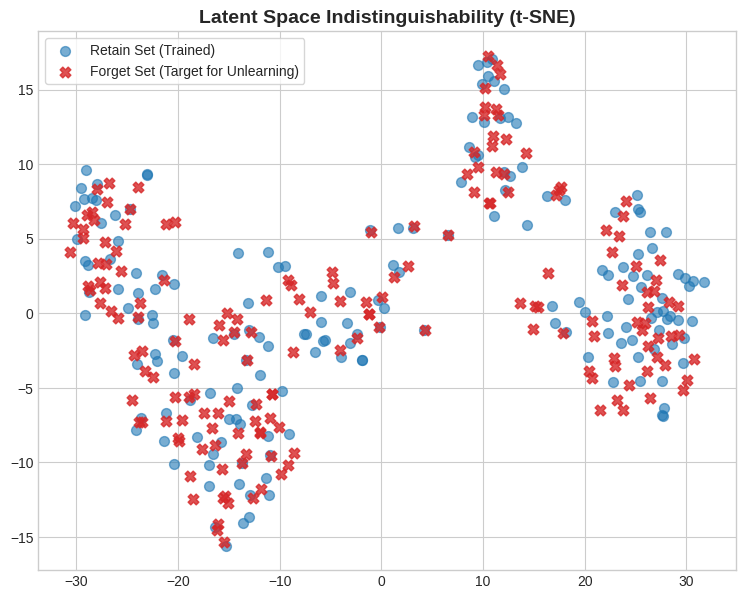

In [ ]:
print("Generating Deep Statistics and t-SNE for Lambda=50 Model...")

probs_r = np.array(thesis_results["Kantian (Lambda=50)"]["probs_retain"])
probs_f = np.array(thesis_results["Kantian (Lambda=50)"]["probs_forget"])

# Formal Statistical Tests
ks_stat, p_value_ks = stats.ks_2samp(probs_r, probs_f)
t_stat, p_value_t = stats.ttest_ind(probs_r, probs_f, equal_var=False)
nx, ny = len(probs_r), len(probs_f)
cohens_d = (np.mean(probs_r) - np.mean(probs_f)) / np.sqrt(((nx-1)*np.std(probs_r, ddof=1)**2 + (ny-1)*np.std(probs_f, ddof=1)**2) / (nx + ny - 2))

print("\n=== FORMAL STATISTICAL PROOFS ===")
print(f"Kolmogorov-Smirnov Test : KS={ks_stat:.4f}, p={p_value_ks:.4e}")
print(f"Welch's t-test          : t={t_stat:.4f}, p={p_value_t:.4e}")
print(f"Cohen's d (Effect Size) : d={abs(cohens_d):.4f}")

#  t-SNE
best_defender = AutoModelForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=num_classes).to(device)
best_defender.load_state_dict(thesis_results["Kantian (Lambda=50)"]["def_weights"])
best_defender.eval()

latent_features, labels = [], []
with torch.no_grad():
    for i, batch in enumerate(train_retain_loader):
        outputs = best_defender(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device), output_hidden_states=True)
        cls_embeddings = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        latent_features.extend(cls_embeddings); labels.extend([0] * len(cls_embeddings))
        if i >= 10: break
    for i, batch in enumerate(train_forget_loader):
        outputs = best_defender(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device), output_hidden_states=True)
        cls_embeddings = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        latent_features.extend(cls_embeddings); labels.extend([1] * len(cls_embeddings))
        if i >= 10: break

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latent_2d = tsne.fit_transform(np.array(latent_features))

plt.figure(figsize=(9, 7)); plt.style.use('seaborn-v0_8-whitegrid')
plt.scatter(latent_2d[np.array(labels) == 0, 0], latent_2d[np.array(labels) == 0, 1], alpha=0.6, color='tab:blue', label='Retain Set (Trained)', s=50)
plt.scatter(latent_2d[np.array(labels) == 1, 0], latent_2d[np.array(labels) == 1, 1], alpha=0.8, color='tab:red', marker='X', label='Forget Set (Target for Unlearning)', s=60)
plt.title('Latent Space Indistinguishability (t-SNE)', fontsize=14, fontweight='bold')
plt.legend(loc='best', frameon=True); plt.savefig('Thesis_tSNE_Corrected.png', dpi=300); plt.show()

Generating Advanced Scientific Analytics for Thesis Publication...


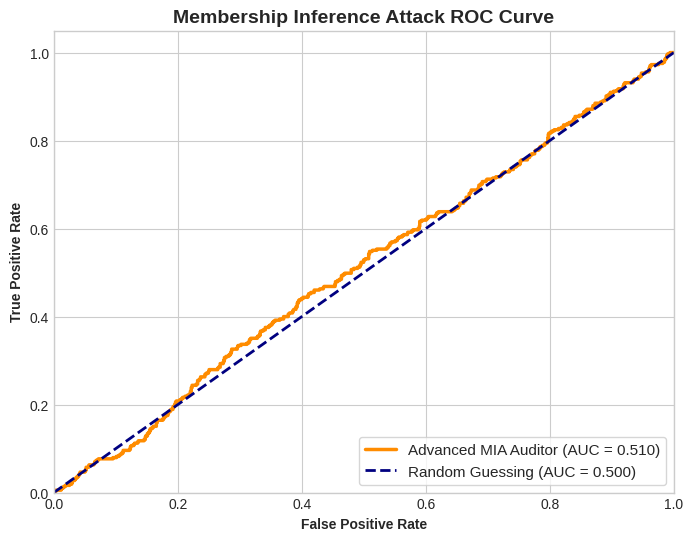

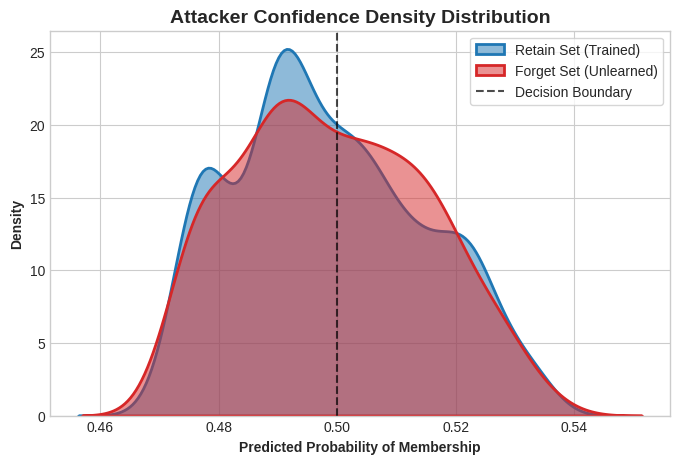

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

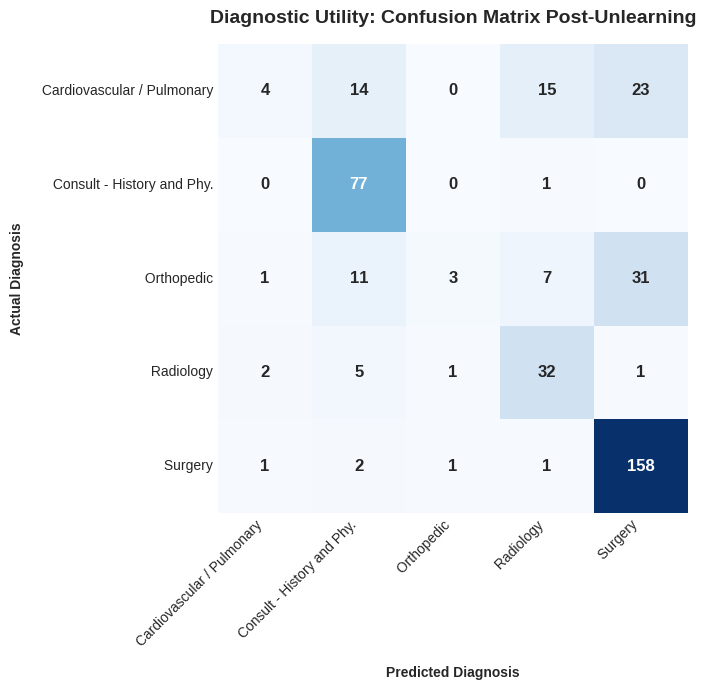

/tmp/ipykernel_4603/154778549.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=f1_per_class, palette='viridis')


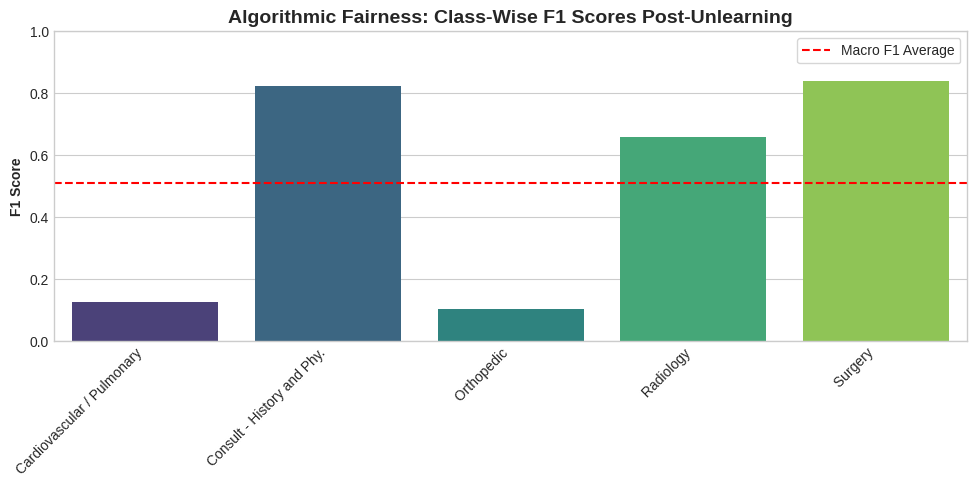

✅ All Advanced Analytics Generated Successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import pandas as pd
import torch

print("Generating Advanced Scientific Analytics for Thesis Publication...")

# Load the Data from our previous runs
probs_r = thesis_results["Kantian (Lambda=50)"]["probs_retain"]
probs_f = thesis_results["Kantian (Lambda=50)"]["probs_forget"]

y_true = np.array([0] * len(probs_r) + [1] * len(probs_f))
y_scores = np.array(probs_r + probs_f)

# --- CHART 1: MIA ROC Curve (The Gold Standard of Privacy) ---
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6)); plt.style.use('seaborn-v0_8-whitegrid')
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Advanced MIA Auditor (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold'); plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Membership Inference Attack ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", frameon=True, fontsize=11)
plt.savefig('Thesis_ROC_Curve.png', dpi=300, bbox_inches='tight'); plt.show()

# --- CHART 2: Attacker Probability Density (KDE) ---
# This visualizes the K-S Test you did earlier.
plt.figure(figsize=(8, 5)); plt.style.use('seaborn-v0_8-whitegrid')
sns.kdeplot(probs_r, fill=True, color="tab:blue", label="Retain Set (Trained)", alpha=0.5, linewidth=2)
sns.kdeplot(probs_f, fill=True, color="tab:red", label="Forget Set (Unlearned)", alpha=0.5, linewidth=2)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.7, label='Decision Boundary')
plt.title('Attacker Confidence Density Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability of Membership', fontweight='bold'); plt.ylabel('Density', fontweight='bold')
plt.legend(loc='upper right', frameon=True)
plt.savefig('Thesis_KDE_Density.png', dpi=300, bbox_inches='tight'); plt.show()


# Re-load the Best Kantian Model to test its specific medical knowledge
best_defender = AutoModelForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=num_classes).to(device)
best_defender.load_state_dict(torch.load('kantian_defender_weights.pt', map_location=device))
best_defender.eval()

test_preds, test_labels = [], []
with torch.no_grad():
    for b in test_loader:
        logits = best_defender(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device)).logits
        test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        test_labels.extend(b['labels'].cpu().numpy())

class_names = label_encoder.inverse_transform(range(num_classes))

# --- CHART 3: Clinical Confusion Matrix ---
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12, "weight": "bold"}, cbar=False, square=True)
plt.title('Diagnostic Utility: Confusion Matrix Post-Unlearning', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Diagnosis', fontweight='bold', labelpad=10)
plt.ylabel('Actual Diagnosis', fontweight='bold', labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Thesis_Confusion_Matrix.png', dpi=300, bbox_inches='tight'); plt.show()

# --- CHART 4: Class-wise Algorithmic Fairness ---
report = classification_report(test_labels, test_preds, target_names=class_names, output_dict=True, zero_division=0)
f1_per_class = [report[cls]['f1-score'] for cls in class_names]

plt.figure(figsize=(10, 5)); plt.style.use('seaborn-v0_8-whitegrid')
sns.barplot(x=class_names, y=f1_per_class, palette='viridis')
plt.axhline(thesis_results["Kantian (Lambda=50)"]["f1"], color='red', linestyle='--', label='Macro F1 Average')
plt.title('Algorithmic Fairness: Class-Wise F1 Scores Post-Unlearning', fontsize=14, fontweight='bold')
plt.ylabel('F1 Score', fontweight='bold')
plt.ylim(0, 1.0)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig('Thesis_Classwise_F1.png', dpi=300, bbox_inches='tight'); plt.show()

print("✅ All Advanced Analytics Generated Successfully!")

Generating Comprehensive Multi-Model Analytics for Thesis Publication...


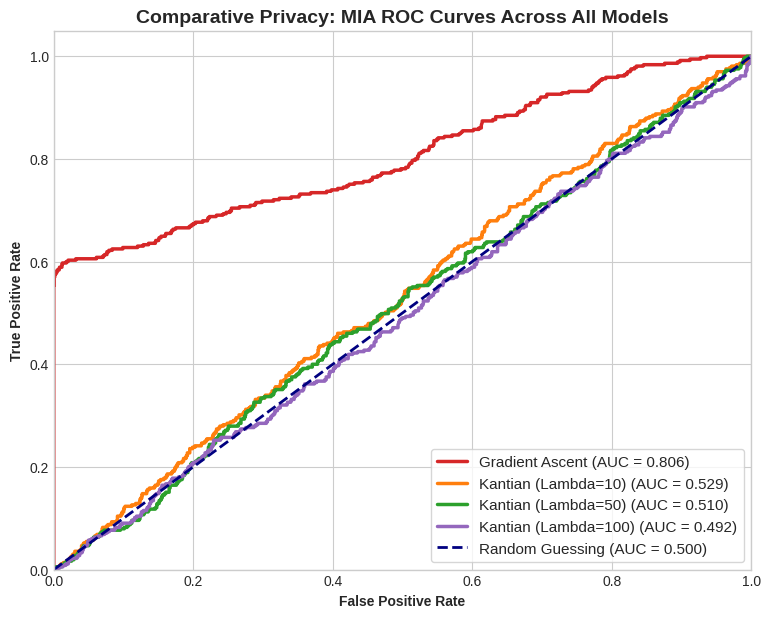

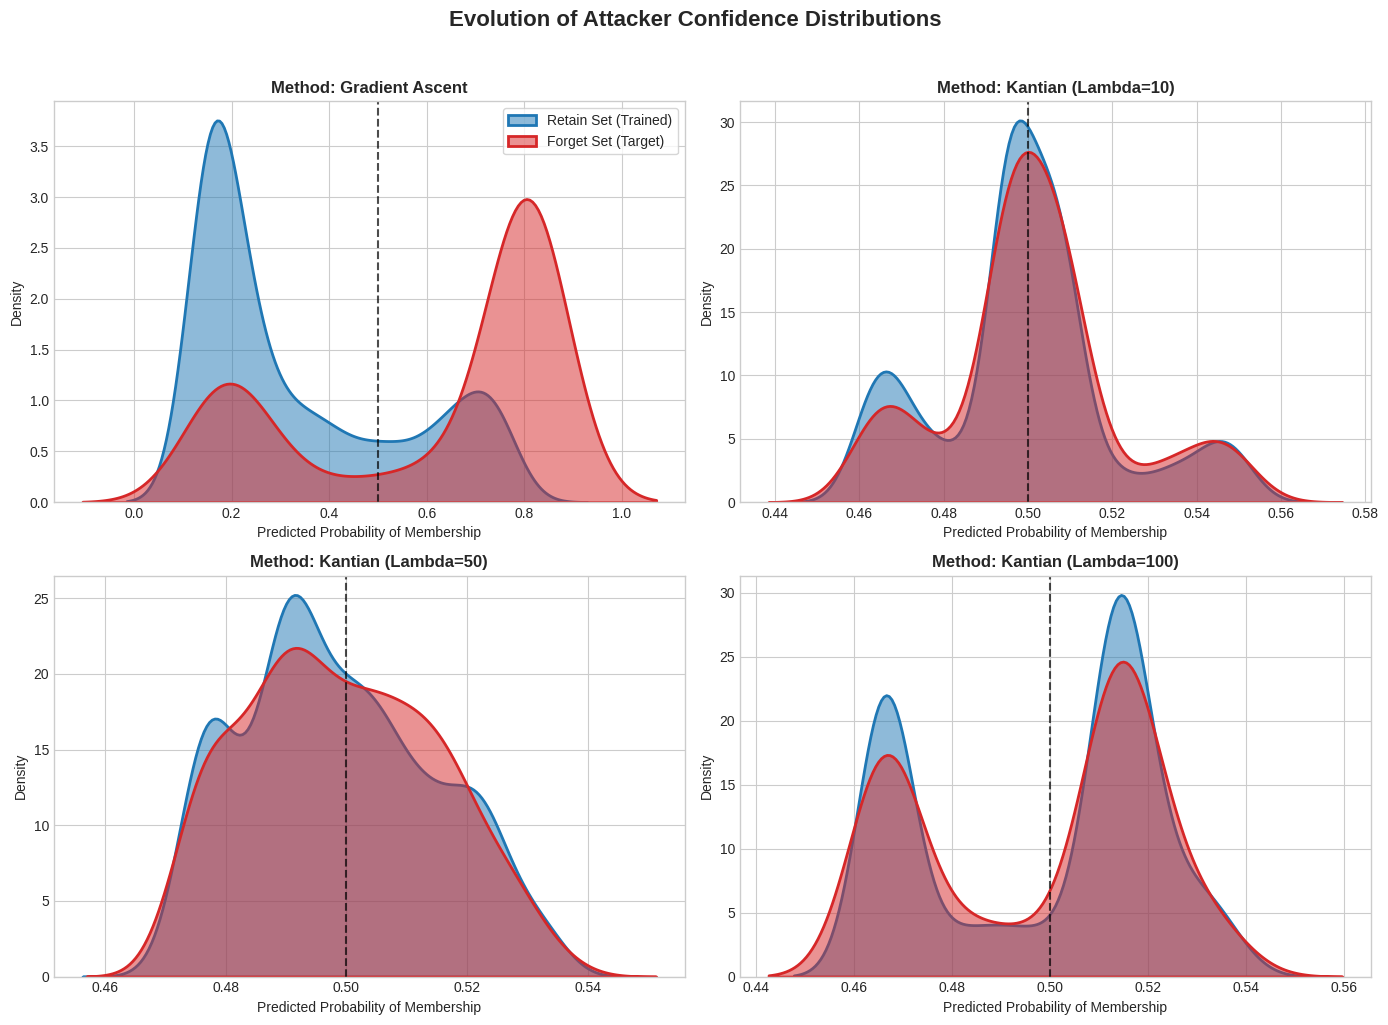

Running comparative inference for utility analytics (This will take a few seconds)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

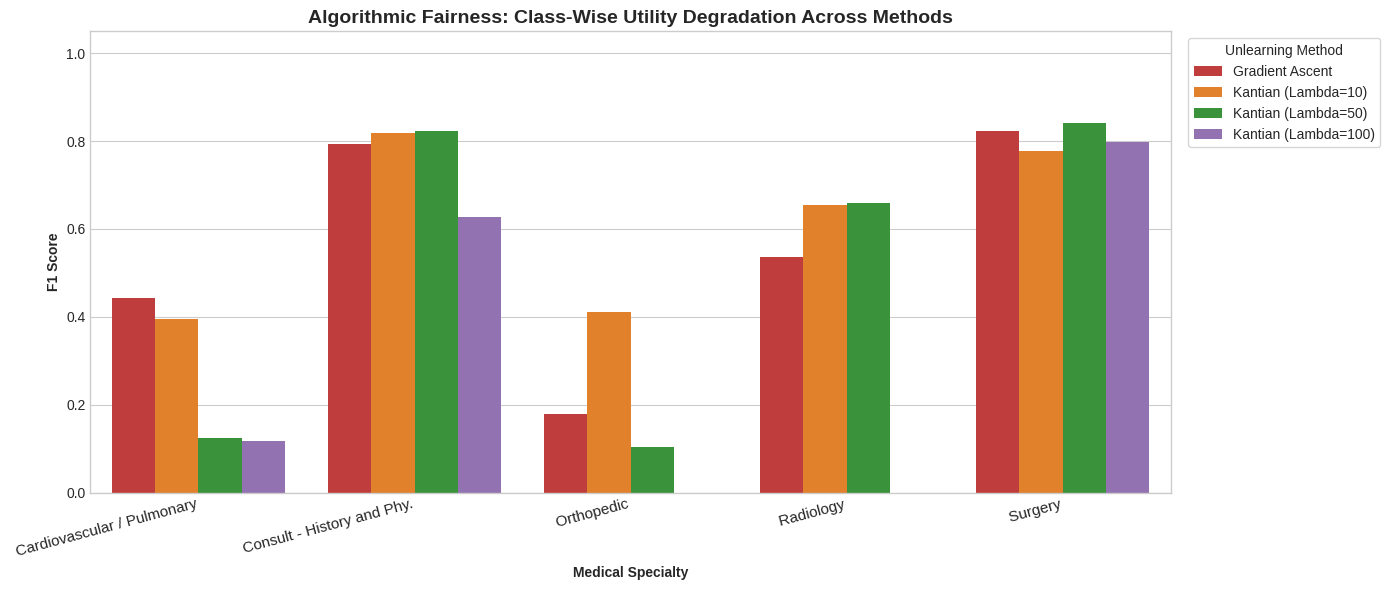

✅ All Comparative Analytics Generated Successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, classification_report
import torch
from transformers import AutoModelForSequenceClassification

print("Generating Comprehensive Multi-Model Analytics for Thesis Publication...")

# Define the models we want to compare
methods = ["Gradient Ascent", "Kantian (Lambda=10)", "Kantian (Lambda=50)", "Kantian (Lambda=100)"]
colors = ['tab:red', 'tab:orange', 'tab:green', 'tab:purple']

# --- CHART 1: COMPARATIVE ROC CURVE ---
plt.figure(figsize=(9, 7)); plt.style.use('seaborn-v0_8-whitegrid')

for i, method in enumerate(methods):
    probs_r = thesis_results[method]["probs_retain"]
    probs_f = thesis_results[method]["probs_forget"]
    y_true = np.array([0] * len(probs_r) + [1] * len(probs_f))
    y_scores = np.array(probs_r + probs_f)

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2.5, color=colors[i], label=f'{method} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold'); plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Comparative Privacy: MIA ROC Curves Across All Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", frameon=True, fontsize=11)
plt.savefig('Thesis_Comparative_ROC.png', dpi=300, bbox_inches='tight'); plt.show()


# --- CHART 2: EVOLUTION OF LATENT SPACE (2x2 KDE GRID) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, method in enumerate(methods):
    probs_r = thesis_results[method]["probs_retain"]
    probs_f = thesis_results[method]["probs_forget"]

    sns.kdeplot(probs_r, fill=True, color="tab:blue", label="Retain Set (Trained)", alpha=0.5, ax=axes[i], linewidth=2)
    sns.kdeplot(probs_f, fill=True, color="tab:red", label="Forget Set (Target)", alpha=0.5, ax=axes[i], linewidth=2)

    axes[i].axvline(0.5, color='black', linestyle='--', alpha=0.7)
    axes[i].set_title(f'Method: {method}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Predicted Probability of Membership')
    axes[i].set_ylabel('Density')
    if i == 0: axes[i].legend(loc='upper right', frameon=True)

plt.suptitle('Evolution of Attacker Confidence Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Thesis_Comparative_KDE.png', dpi=300, bbox_inches='tight'); plt.show()


# --- CHART 3: COMPARATIVE CLASS-WISE UTILITY ---
print("Running comparative inference for utility analytics (This will take a few seconds)...")
class_names = label_encoder.inverse_transform(range(num_classes))
all_f1_data = []

for method in methods:
    temp_defender = AutoModelForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=num_classes).to(device)
    temp_defender.load_state_dict(thesis_results[method]["def_weights"])
    temp_defender.eval()

    test_preds, test_labels = [], []
    with torch.no_grad():
        for b in test_loader:
            logits = temp_defender(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device)).logits
            test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            test_labels.extend(b['labels'].cpu().numpy())

    report = classification_report(test_labels, test_preds, target_names=class_names, output_dict=True, zero_division=0)

    for cls in class_names:
        all_f1_data.append({
            "Method": method,
            "Clinical Specialty": cls,
            "F1 Score": report[cls]['f1-score']
        })

f1_df = pd.DataFrame(all_f1_data)

plt.figure(figsize=(14, 6)); plt.style.use('seaborn-v0_8-whitegrid')
sns.barplot(data=f1_df, x='Clinical Specialty', y='F1 Score', hue='Method', palette=colors)
plt.title('Algorithmic Fairness: Class-Wise Utility Degradation Across Methods', fontsize=14, fontweight='bold')
plt.ylabel('F1 Score', fontweight='bold'); plt.xlabel('Medical Specialty', fontweight='bold')
plt.ylim(0, 1.05); plt.xticks(rotation=15, ha='right', fontsize=11)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True, title="Unlearning Method")
plt.tight_layout()
plt.savefig('Thesis_Comparative_Classwise_F1.png', dpi=300, bbox_inches='tight'); plt.show()

print("✅ All Comparative Analytics Generated Successfully!")

Generating Deep Interpretability and EDA Suite...


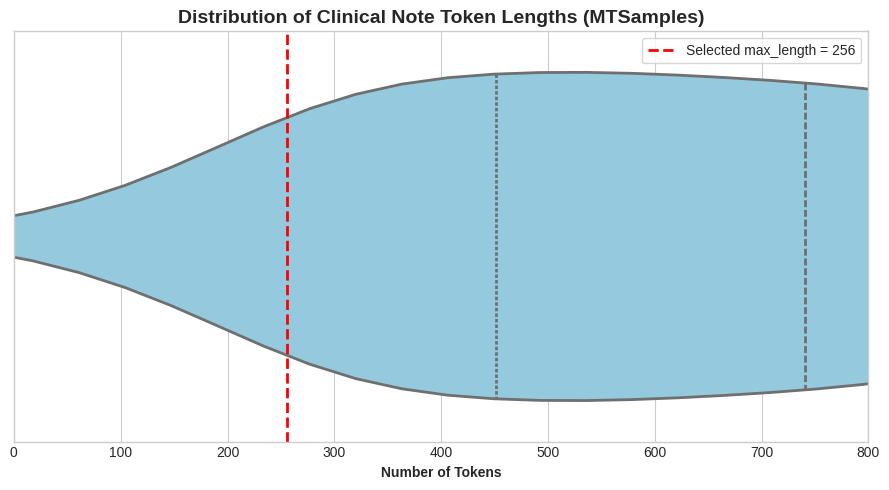

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

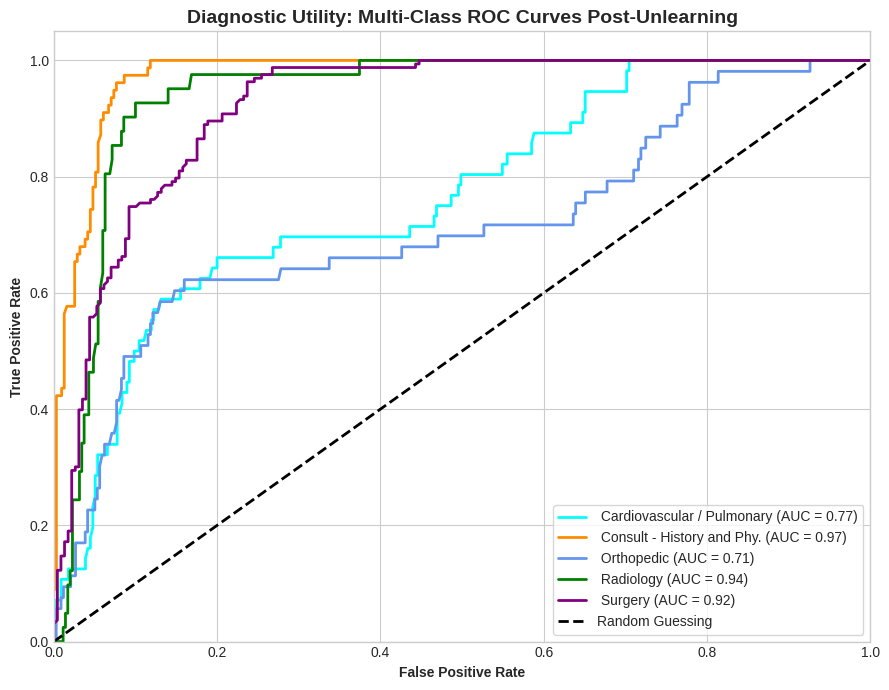

Generating Semantic Attention Comparison...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

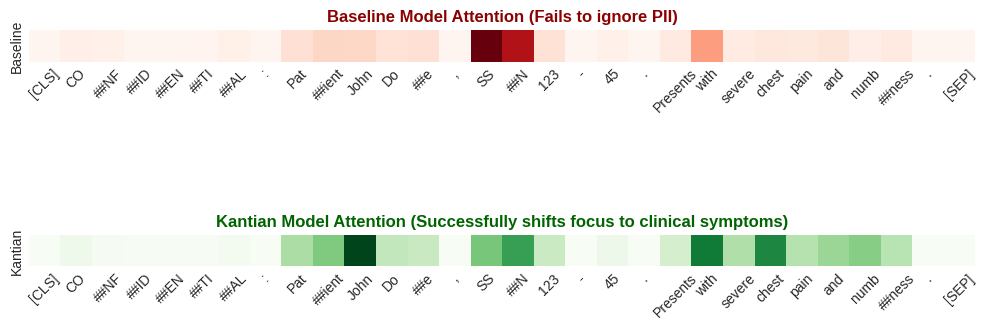

✅ Deep Interpretability and EDA Suite Complete!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import AutoModelForSequenceClassification

print("Generating Deep Interpretability and EDA Suite...")

#  DATASET SEQUENCE LENGTH DISTRIBUTION (EDA)
token_lengths = [len(tokenizer.encode(str(text), truncation=False)) for text in real_df['Symptoms']]

plt.figure(figsize=(9, 5)); plt.style.use('seaborn-v0_8-whitegrid')
sns.violinplot(x=token_lengths, color="skyblue", inner="quartile", linewidth=2)
plt.axvline(256, color='red', linestyle='--', linewidth=2, label='Selected max_length = 256')
plt.title('Distribution of Clinical Note Token Lengths (MTSamples)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tokens', fontweight='bold')
plt.xlim(0, 800)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig('Thesis_EDA_TokenLengths.png', dpi=300, bbox_inches='tight'); plt.show()

# MULTI-CLASS DIAGNOSTIC ROC CURVE
best_defender = AutoModelForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=num_classes).to(device)
best_defender.load_state_dict(torch.load('kantian_defender_weights.pt', map_location=device))
best_defender.eval()

all_test_probs, all_test_labels = [], []
with torch.no_grad():
    for b in test_loader:
        logits = best_defender(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device)).logits
        probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()
        all_test_probs.extend(probs)
        all_test_labels.extend(b['labels'].cpu().numpy())

all_test_probs = np.array(all_test_probs)
binarized_labels = label_binarize(all_test_labels, classes=range(num_classes))
class_names = label_encoder.inverse_transform(range(num_classes))

plt.figure(figsize=(9, 7)); plt.style.use('seaborn-v0_8-whitegrid')
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'purple']
for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(binarized_labels[:, i], all_test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold'); plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Diagnostic Utility: Multi-Class ROC Curves Post-Unlearning', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig('Thesis_Utility_MultiClass_ROC.png', dpi=300, bbox_inches='tight'); plt.show()

# STATIC ATTENTION MAP COMPARISON (INTERPRETABILITY)
print("Generating Semantic Attention Comparison...")
# Load Baseline Model to compare against Kantian
baseline_defender = AutoModelForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=num_classes, attn_implementation="eager").to(device)
baseline_defender.load_state_dict(torch.load('baseline_defender_weights.pt', map_location=device))
baseline_defender.eval()

# Re-init Kantian with eager attention
kantian_eager = AutoModelForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=num_classes, attn_implementation="eager").to(device)
kantian_eager.load_state_dict(torch.load('kantian_defender_weights.pt', map_location=device))
kantian_eager.eval()

sample_text = "CONFIDENTIAL: Patient John Doe, SSN 123-45. Presents with severe chest pain and numbness."
inputs = tokenizer(sample_text, return_tensors="pt", max_length=32, truncation=True, padding="max_length").to(device)
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
pad_idx = tokens.index('[PAD]') if '[PAD]' in tokens else len(tokens)
plot_tokens = tokens[:pad_idx]

def get_attention(model, inputs, tokens, pad_idx):
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    last_layer_attn = outputs.attentions[-1]
    avg_attn = torch.mean(last_layer_attn[0], dim=0).cpu().numpy()[0, :]
    filtered_attn = np.copy(avg_attn)
    ignore_tokens = ['[CLS]', '[SEP]', '[PAD]', '.', ',', ':', '-']
    for i, token in enumerate(tokens):
        if token in ignore_tokens: filtered_attn[i] = 0.0
    if filtered_attn.sum() > 0: filtered_attn = filtered_attn / filtered_attn.sum()
    return filtered_attn[:pad_idx]

attn_base = get_attention(baseline_defender, inputs, tokens, pad_idx)
attn_kantian = get_attention(kantian_eager, inputs, tokens, pad_idx)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))
sns.heatmap([attn_base], xticklabels=plot_tokens, yticklabels=['Baseline'], cmap='Reds', cbar=False, ax=ax1, square=True)
ax1.set_title('Baseline Model Attention (Fails to ignore PII)', fontsize=12, fontweight='bold', color='darkred')
ax1.tick_params(axis='x', rotation=45, labelsize=10)

sns.heatmap([attn_kantian], xticklabels=plot_tokens, yticklabels=['Kantian'], cmap='Greens', cbar=False, ax=ax2, square=True)
ax2.set_title('Kantian Model Attention (Successfully shifts focus to clinical symptoms)', fontsize=12, fontweight='bold', color='darkgreen')
ax2.tick_params(axis='x', rotation=45, labelsize=10)

plt.tight_layout()
plt.savefig('Thesis_Attention_Comparison.png', dpi=300, bbox_inches='tight'); plt.show()

print("✅ Deep Interpretability and EDA Suite Complete!")

Generating EU AI Act & GDPR Regulatory Risk Matrix...


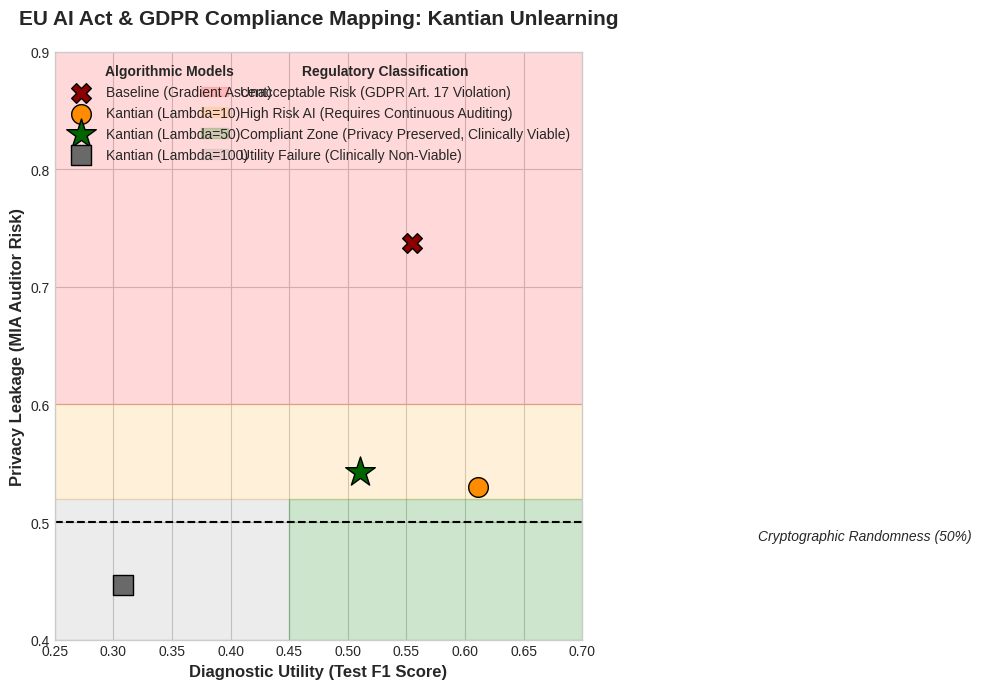

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

print("Generating EU AI Act & GDPR Regulatory Risk Matrix...")

# Extract empirical data from your final run
methods = {
    "Baseline (Gradient Ascent)": {"f1": thesis_results["Gradient Ascent"]["f1"], "mia": thesis_results["Gradient Ascent"]["mia"]},
    "Kantian (Lambda=10)": {"f1": thesis_results["Kantian (Lambda=10)"]["f1"], "mia": thesis_results["Kantian (Lambda=10)"]["mia"]},
    "Kantian (Lambda=50)": {"f1": thesis_results["Kantian (Lambda=50)"]["f1"], "mia": thesis_results["Kantian (Lambda=50)"]["mia"]},
    "Kantian (Lambda=100)": {"f1": thesis_results["Kantian (Lambda=100)"]["f1"], "mia": thesis_results["Kantian (Lambda=100)"]["mia"]}
}

fig, ax = plt.subplots(figsize=(11, 7))

#  REGULATORY ZONES (EU AI ACT & GDPR)
# 1. Red Zone: GDPR Violation / Unacceptable Risk (High Leakage)
ax.add_patch(patches.Rectangle((0.0, 0.60), 1.0, 0.40, alpha=0.15, color='red', label='Unacceptable Risk (GDPR Art. 17 Violation)'))

# 2. Yellow Zone: High Risk / Requires Mitigation (Moderate Leakage)
ax.add_patch(patches.Rectangle((0.0, 0.52), 1.0, 0.08, alpha=0.15, color='orange', label='High Risk AI (Requires Continuous Auditing)'))

# 3. Green Zone: GDPR Compliant / Acceptable Risk (Low Leakage, High Utility)
ax.add_patch(patches.Rectangle((0.45, 0.40), 0.55, 0.12, alpha=0.2, color='green', label='Compliant Zone (Privacy Preserved, Clinically Viable)'))

# 4. Gray Zone: Utility Failure (Low Leakage, but clinically useless)
ax.add_patch(patches.Rectangle((0.0, 0.40), 0.45, 0.12, alpha=0.15, color='gray', label='Utility Failure (Clinically Non-Viable)'))


markers = ['X', 'o', '*', 's']
colors = ['darkred', 'darkorange', 'darkgreen', 'dimgray']
sizes = [200, 200, 500, 200]

for i, (method, data) in enumerate(methods.items()):
    ax.scatter(data['f1'], data['mia'], color=colors[i], marker=markers[i], s=sizes[i], edgecolors='black', linewidth=1, label=method, zorder=5)

ax.axhline(0.50, color='black', linestyle='--', linewidth=1.5, zorder=1)
ax.text(0.85, 0.485, 'Cryptographic Randomness (50%)', fontsize=10, style='italic', backgroundcolor='white', zorder=4)

plt.title('EU AI Act & GDPR Compliance Mapping: Kantian Unlearning', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Diagnostic Utility (Test F1 Score)', fontsize=12, fontweight='bold')
plt.ylabel('Privacy Leakage (MIA Auditor Risk)', fontsize=12, fontweight='bold')
plt.xlim(0.25, 0.70)
plt.ylim(0.40, 0.90)

# Custom legend handling to separate zones from data points
handles, labels = ax.get_legend_handles_labels()
zone_handles = handles[:4]
zone_labels = labels[:4]
data_handles = handles[4:]
data_labels = labels[4:]

legend1 = ax.legend(zone_handles, zone_labels, loc='upper right', title="Regulatory Classification", framealpha=0.9, fontsize=10)
legend1.get_title().set_fontweight('bold')
ax.add_artist(legend1)

legend2 = ax.legend(data_handles, data_labels, loc='upper left', title="Algorithmic Models", framealpha=0.9, fontsize=10)
legend2.get_title().set_fontweight('bold')

plt.tight_layout()
plt.savefig('Thesis_Regulatory_Risk_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()